# Caption Task

## Teste formado de submissão

In [1]:
import os
os.getcwd()

'/home/ia368/projetos/imageclef2026-rag/notebooks'

In [2]:
os.chdir("/home/ia368/projetos/imageclef2026-rag")
os.getcwd()

'/home/ia368/projetos/imageclef2026-rag'

In [3]:
import pandas as pd

captions = pd.read_csv('dev_caption/captions.csv')
captions.head()

# selecionar somente elementos de valid
# regex para onde ID contem _valid_
captions_valid = captions[captions['ID'].str.contains('_valid_')]
captions_valid.head()

captions_valid.to_csv('evaluation/caption_prediction/data/valid/captions.csv', index=False)

In [4]:
!python evaluation/caption_prediction/submission_check.py \
  --submission artifacts/results/submission.csv \
  --dataset valid \
  --ground-truth evaluation/caption_prediction/data/valid/captions.csv

Submission format check passed.


In [ ]:
!grep -n '^[[:space:]]*$' caminho/do/arquivo.csv

# Avaliacao simplificada

In [17]:
# BERTScore
from bert_score import score as bertscore

# ROUGE
from rouge_score import rouge_scorer

# BLEURT
from bleurt import score as bleurt_score

import tqdm
import torch


In [28]:
def evaluate(
    submission_path,
    ground_truth_path,
    bleurt_checkpoint=None,
    output_path="detailed_scores.csv"
):
    print("Loading files...")
    sub = pd.read_csv(submission_path)
    gt = pd.read_csv(ground_truth_path)

    # Merge on ID
    df = pd.merge(gt, sub, on="ID", suffixes=("_gt", "_pred"))

    references = df["Caption_gt"].tolist()
    candidates = df["Caption_pred"].tolist()

    print(f"Total samples: {len(df)}")

    # -------------------------
    # BERTScore
    # -------------------------
    print("Computing BERTScore...")
    P, R, F1 = bertscore(candidates, references, lang="en", verbose=True)
    df["bertscore_f1"] = F1.numpy()

    # -------------------------
    # ROUGE
    # -------------------------
    print("Computing ROUGE...")
    rouge = rouge_scorer.RougeScorer(
        ["rouge1", "rouge2", "rougeL"],
        use_stemmer=True
    )

    rouge1 = []
    rouge2 = []
    rougeL = []

    for ref, pred in tqdm.tqdm(zip(references, candidates), total=len(df)):
        scores = rouge.score(ref, pred)
        rouge1.append(scores["rouge1"].fmeasure)
        rouge2.append(scores["rouge2"].fmeasure)
        rougeL.append(scores["rougeL"].fmeasure)

    df["rouge1"] = rouge1
    df["rouge2"] = rouge2
    df["rougeL"] = rougeL

    # -------------------------
    # BLEURT
    # -------------------------
    print("Computing BLEURT (CPU)...")
    checkpoint_to_use = bleurt_checkpoint
    if checkpoint_to_use and not os.path.exists(checkpoint_to_use):
        print(f"Checkpoint '{checkpoint_to_use}' não encontrado. Usando checkpoint padrão do BLEURT.")
        checkpoint_to_use = None

    import tensorflow as tf
    with tf.device('/CPU:0'):
        bleurt_scorer = bleurt_score.BleurtScorer(checkpoint_to_use)
        bleurt_scores = bleurt_scorer.score(
            references=references,
            candidates=candidates
        )
    df["bleurt"] = bleurt_scores

    # -------------------------
    # Print averages
    # -------------------------
    print("\n===== AVERAGE SCORES =====")
    print("BERTScore F1:", df["bertscore_f1"].mean())
    print("ROUGE-1:", df["rouge1"].mean())
    print("BLEURT:", df["bleurt"].mean())

    # Save detailed results
    df.to_csv(output_path, index=False)
    print(f"\nDetailed results saved to {output_path}")


In [31]:
evaluate(
    submission_path="artifacts/results/submission.csv",
    ground_truth_path="evaluation/caption_prediction/data/valid/captions.csv",
    bleurt_checkpoint=None,
    output_path="artifacts/results/detailed_scores.csv"
 )

Loading files...
Total samples: 19240
Computing BERTScore...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


  0%|          | 0/590 [00:00<?, ?it/s]

...

INFO:tensorflow:Loading model.


INFO:tensorflow:Loading model.


INFO:tensorflow:BLEURT initialized.


INFO:tensorflow:BLEURT initialized.



===== AVERAGE SCORES =====
BERTScore F1: 0.8676336
ROUGE-1: 0.23802232458084085
BLEURT: -0.7523124743950033

Detailed results saved to artifacts/results/detailed_scores.csv


In [32]:
results = pd.read_csv("artifacts/results/detailed_scores.csv")
results.head()

,ID,Caption_gt,Caption_pred,bertscore_f1,rouge1,rouge2,rougeL,bleurt
0,ImageCLEFmedical_Caption_2026_valid_0,There is a little long T1 and long T2 signal n...,"MRI of the brain, showing a clear view of the ...",0.855183,0.238806,0.061538,0.179104,-1.075554
1,ImageCLEFmedical_Caption_2026_valid_1,The bilateral frontotemporal extracerebral spa...,Axial T2-weighted MRI of the brain showing sym...,0.843937,0.200000,0.105263,0.200000,-0.977295
2,ImageCLEFmedical_Caption_2026_valid_2,Sagittal STIR sequence of the lumbar spine sho...,"Sagittal MRI of the lumbar spine, showing a po...",0.890044,0.327273,0.150943,0.327273,-0.726906
3,ImageCLEFmedical_Caption_2026_valid_3,Post-operative radiograph of pelvis with both ...,Post-operative anteroposterior radiograph of t...,0.917392,0.514286,0.181818,0.457143,-0.696231
4,ImageCLEFmedical_Caption_2026_valid_4,Pre-operative radiograph of pelvis with both h...,Postoperative anteroposterior pelvic radiograp...,0.887026,0.339623,0.078431,0.264151,-0.056225


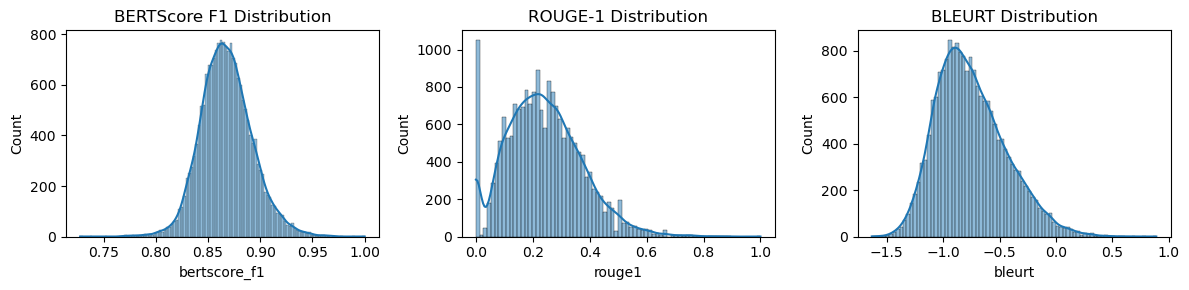

In [35]:
# distribuiçao dos scores
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

sns.histplot(results["bertscore_f1"], ax=axes[0], kde=True)
axes[0].set_title("BERTScore F1 Distribution")

sns.histplot(results["rouge1"], ax=axes[1], kde=True)
axes[1].set_title("ROUGE-1 Distribution")

sns.histplot(results["bleurt"], ax=axes[2], kde=True)
axes[2].set_title("BLEURT Distribution")

plt.tight_layout()
plt.show()

# Avalicação oficial

In [ ]:
! cd evaluation/caption_prediction

In [ ]:
! docker run --rm --gpus '"device=3"' \
  -v "$(pwd)/precomputed:/app/precomputed" \
  caption_prediction_evaluator \
  python3 precompute_embeddings.py --dataset valid
docker build --no-cache -f Dockerfile.valid -t caption_prediction_evaluator .